In [ ]:
#STEP 1 : Perform Exploratory Data Analysis (EDA) on our dataset

# Importing modules 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

#read the dataset
dataset = pd.read_csv('D:\\Project\\creditcard.csv')

# read the first 5 and last 5 rows of the data
dataset.head().append(dataset.tail())


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\NISHA\\Desktop\\Sign\\creditcard.csv'

In [ ]:
#STEP 2 : Apply different Machine Learning algorithms to our dataset

Fraudulent Cases: 492
Valid Transactions: 284315
Proportion of Fraudulent Cases: 0.001727485630620034


<AxesSubplot:ylabel=' '>

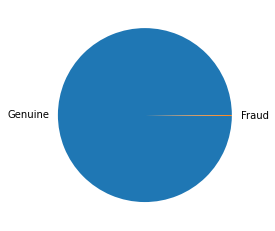

In [ ]:
# Check for relative proportion 
print("Fraudulent Cases: " + str(len(dataset[dataset["Class"] == 1])))
print("Non-fradulent or Valid Transactions: " + str(len(dataset[dataset["Class"] == 0])))
print("Proportion of Fraudulent Cases: " + str(len(dataset[dataset["Class"] == 1])/ dataset.shape[0]))

# To see how small are the number of Fraud transactions
data_p = dataset.copy()
data_p[" "] = np.where(data_p["Class"] == 1 ,  "Fraud", "Genuine")

# Plot a pie chart
data_p[" "].value_counts().plot(kind="pie")

In [ ]:
print("Average Amount in a Fraudulent Transaction: " + str(dataset[dataset["Class"] == 1]["Amount"].mean()))
print("Average Amount in a Non-fradulent or Valid Transaction: " + str(dataset[dataset["Class"] == 0]["Amount"].mean()))
print("Summary of the feature - Amount" + "\n-------------------------------")
print(dataset["Amount"].describe())

Average Amount in a Fraudulent Transaction: 122.21132113821133
Average Amount in a Valid Transaction: 88.29102242225574
Summary of the feature - Amount
-------------------------------
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


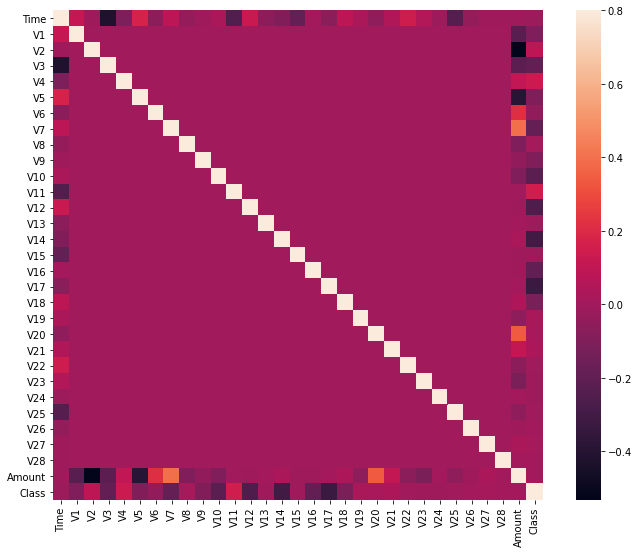

In [ ]:
# Correlation matrix
#The correlation matrix graphically gives us an idea of how features correlate with each other
#Predicts what are the features that are most relevant for the prediction.
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

In [ ]:
# STEP 3 : Train and Evaluate our models on the dataset.

# Split the data into features and labels

X = dataset.drop('Class', axis=1)
y = dataset['Class']

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a random forest classifier
classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Evaluate the model

print("Confusion matrix : ")
print(confusion_matrix(y_test, y_pred))
#The output of the code will be the confusion matrix is [[TN  FP] [FN  TP]]
#TN (True Negative) represents the number of non-fraudulent transactions correctly predicted as non-fraudulent.
#FP (False Positive) represents the number of non-fraudulent transactions incorrectly predicted as fraudulent.
#FN (False Negative) represents the number of fraudulent transactions incorrectly predicted as non-fraudulent.
#TP (True Positive) represents the number of fraudulent transactions correctly predicted as fraudulent.

print("Classifiaction Report : ")
print(classification_report(y_test, y_pred))
#0 - non-fraudulent transactions
#1 - fraudulent transactions

Confusion matrix : 
[[56863     1]
 [   22    76]]
Classifiaction Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.78      0.87        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



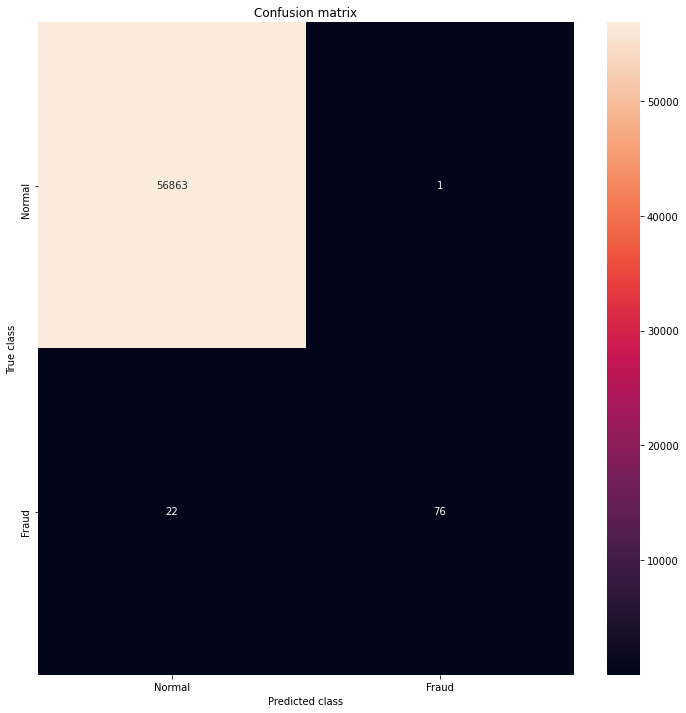

In [ ]:
# Printing the confusion matrix
LABELS = ['Normal', 'Fraud']
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize =(12, 12))
sns.heatmap(conf_matrix, xticklabels = LABELS,yticklabels = LABELS, annot = True, fmt ="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()